## Driver Comparison — 1st vs 2nd during Monaco GP Qualifying 2023

The goal of this analysis is to compare the fastest lap of 
Max Verstappen (1st) and Fernando Alonso (2nd) during the 
2023 Monaco Grand Prix Qualifying.
We will use multi-channel overlay and math channels to 
understand their driving techniques.

Note: This analysis has limitations. Monaco's narrow layout 
forces both drivers onto a near-identical line, resulting in 
very similar overlays. Furthermore, at this level the 
differences between two top drivers are extremely thin — 
math channels are therefore essential to quantify them.

In [ ]:
import fastf1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

session = fastf1.get_session(2023, 'Monaco', 'Q')
session.load()

tel_VER = session.laps.pick_driver('VER').pick_fastest().get_telemetry()
tel_ALO = session.laps.pick_driver('ALO').pick_fastest().get_telemetry()

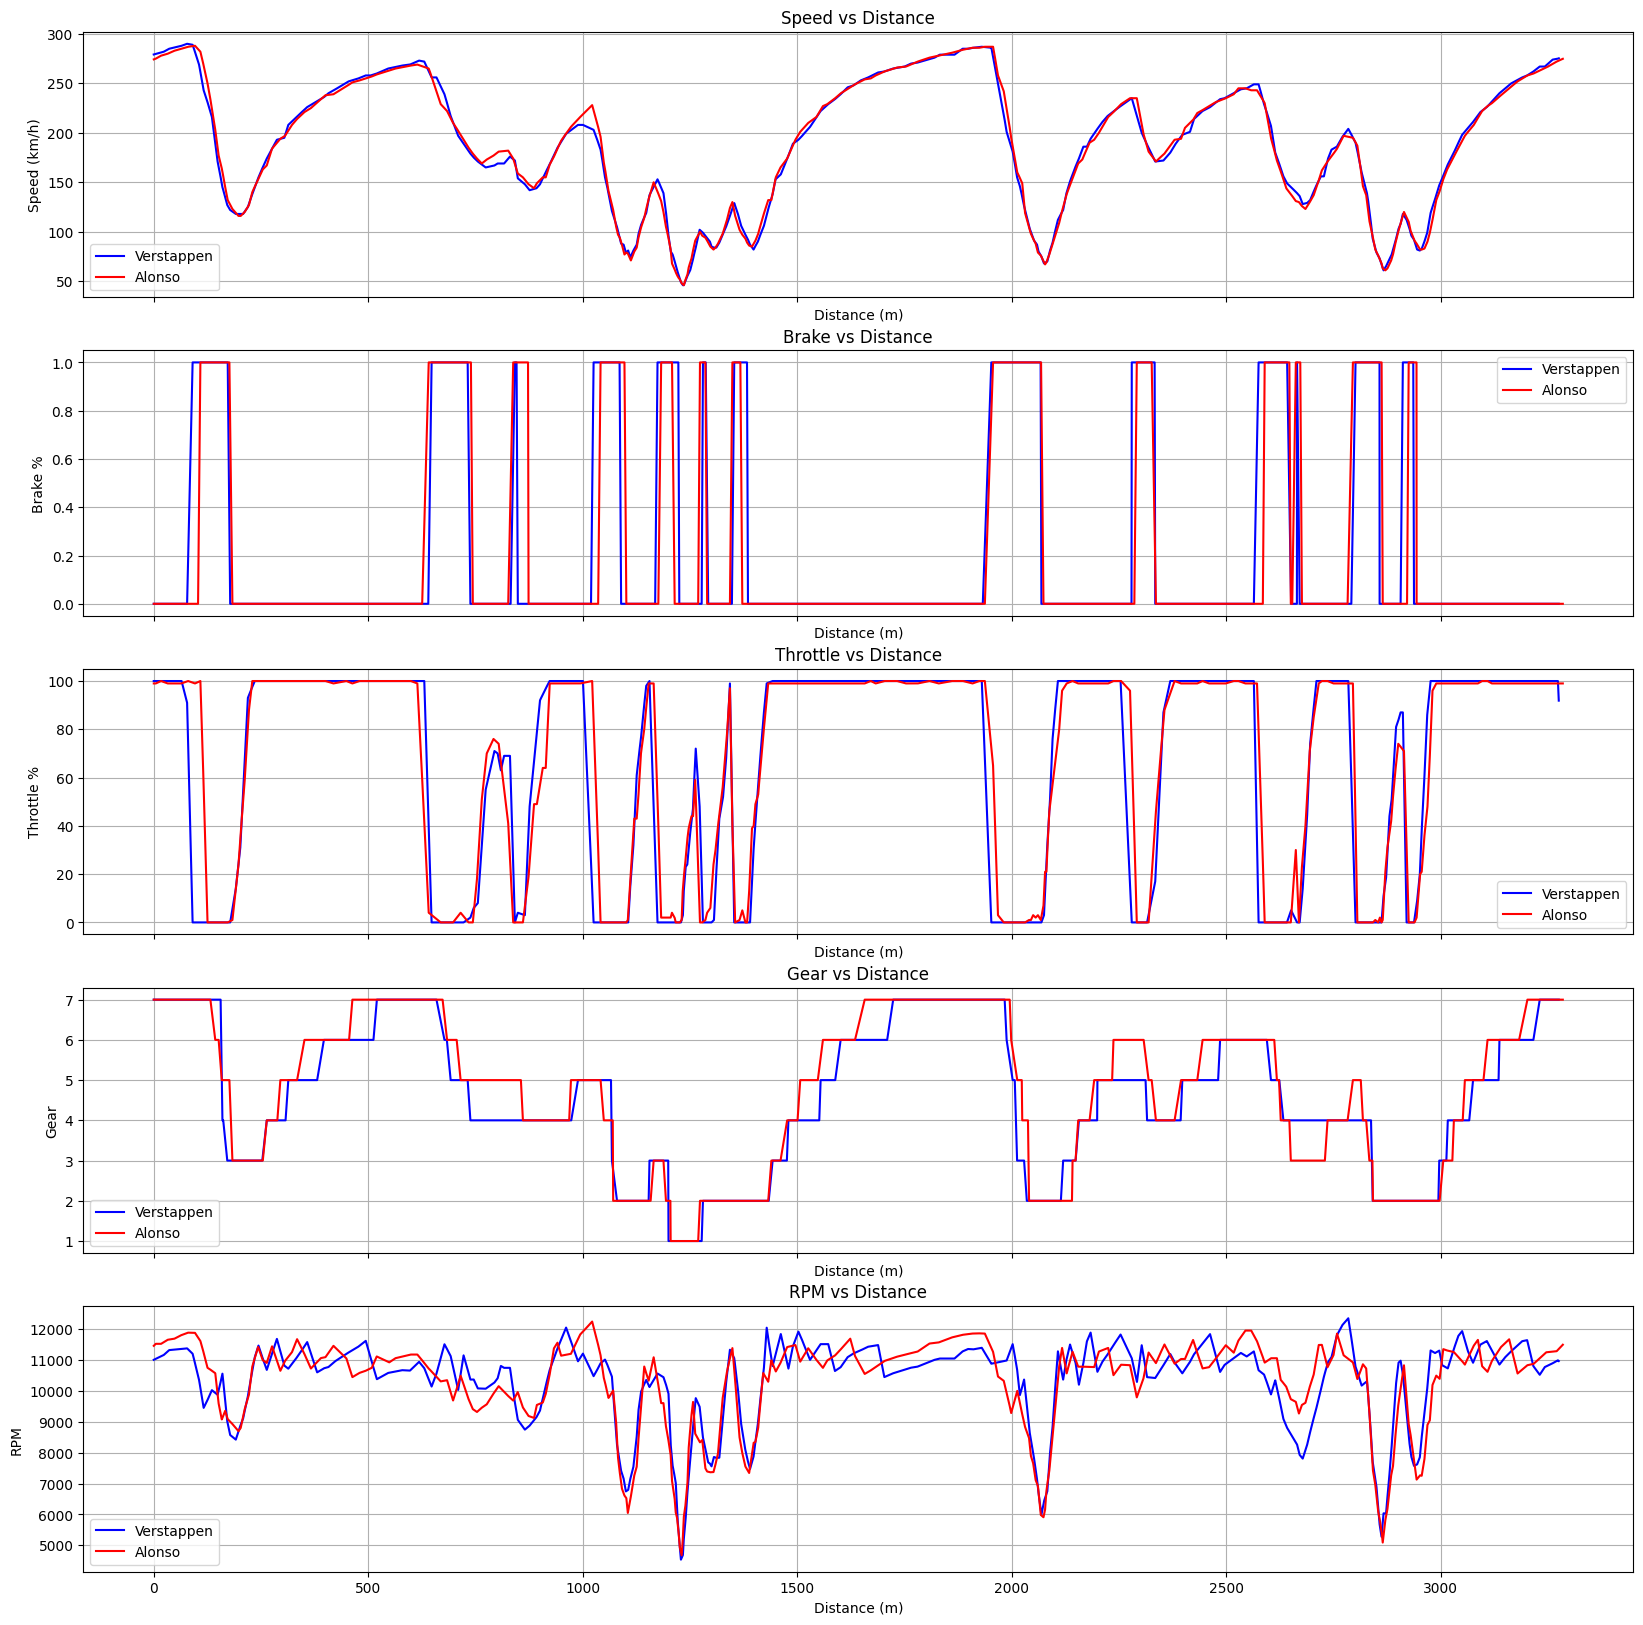

In [18]:
fig, axs = plt.subplots(5, 1, sharex=True, figsize=(20, 20))

#Speed vs Distance
axs[0].plot(tel_VER['Distance'], tel_VER['Speed'], label='Verstappen', color='blue')
axs[0].plot(tel_ALO['Distance'], tel_ALO['Speed'], label='Alonso', color='red')

axs[0].set_title('Speed vs Distance')
axs[0].set_ylabel('Speed (km/h)')
axs[0].set_xlabel('Distance (m)')

axs[0].grid()
axs[0].legend() 

#Brake vs Distance
axs[1].plot(tel_VER['Distance'], tel_VER['Brake'], label='Verstappen', color='blue')
axs[1].plot(tel_ALO['Distance'], tel_ALO['Brake'], label='Alonso', color='red')

axs[1].set_title('Brake vs Distance')
axs[1].set_ylabel('Brake %')
axs[1].set_xlabel('Distance (m)')

axs[1].grid()
axs[1].legend() 

#Throttle vs Distance
axs[2].plot(tel_VER['Distance'], tel_VER['Throttle'], label='Verstappen', color='blue')
axs[2].plot(tel_ALO['Distance'], tel_ALO['Throttle'], label='Alonso', color='red')

axs[2].set_title('Throttle vs Distance')
axs[2].set_ylabel('Throttle %')
axs[2].set_xlabel('Distance (m)')

axs[2].grid()
axs[2].legend()

#Gear vs Distance
axs[3].plot(tel_VER['Distance'], tel_VER['nGear'], label='Verstappen', color='blue')
axs[3].plot(tel_ALO['Distance'], tel_ALO['nGear'], label='Alonso', color='red') 

axs[3].set_title('Gear vs Distance')
axs[3].set_ylabel('Gear')
axs[3].set_xlabel('Distance (m)')

axs[3].grid()
axs[3].legend()

#RPM vs Distance
axs[4].plot(tel_VER['Distance'], tel_VER['RPM'], label='Verstappen', color='blue')
axs[4].plot(tel_ALO['Distance'], tel_ALO['RPM'], label='Alonso', color='red')       

axs[4].set_title('RPM vs Distance')
axs[4].set_ylabel('RPM')
axs[4].set_xlabel('Distance (m)')

axs[4].grid()
axs[4].legend()

plt.show()



## Visual Overlay Analysis

### Observations
- At Monaco, both drivers follow a near-identical 
  line due to the circuit's narrow nature
- Braking points are very similar across all corners
- Minor gear strategy differences visible on nGear channel

### Conclusion
Given the level of both drivers and Monaco's unique 
characteristics, visual overlay analysis shows limited 
differentiation. Quantitative math channels provide 
more meaningful insights — see analysis below.

## Math Channels

In [ ]:
full_throttle_VER = tel_VER[tel_VER['Throttle'] >= 95]
full_throttle_ALO = tel_ALO[tel_ALO['Throttle'] >= 95]

delta_t_VER = full_throttle_VER['Time'].diff()
delta_t_clean = delta_t_VER[delta_t_VER < pd.Timedelta('0.5s')]
temps_full_throttle_VER = delta_t_clean.sum()

delta_t_ALO = full_throttle_ALO['Time'].diff()
delta_t_clean_ALO = delta_t_ALO[delta_t_ALO < pd.Timedelta('0.5s')]
temps_full_throttle_ALO = delta_t_clean_ALO.sum()

VER_full_throttle_percent = (temps_full_throttle_VER / full_throttle_VER['Time'].max()) * 100
ALO_full_throttle_percent = (temps_full_throttle_ALO / full_throttle_ALO['Time'].max()) * 100

corners_VER = tel_VER[tel_VER['Speed'] < 150]
corners_ALO = tel_ALO[tel_ALO['Speed'] < 150]

min_speed_VER = corners_VER['Speed'].mean()
min_speed_ALO = corners_ALO['Speed'].mean()


print(f"Full throttle time for Verstappen : {temps_full_throttle_VER}")
print(f"Full throttle time for Alonso : {temps_full_throttle_ALO}")
print(f"Percentage of time in full throttle for Verstappen : {VER_full_throttle_percent:.2f}%")
print(f"Percentage of time in full throttle for Alonso : {ALO_full_throttle_percent:.2f}%")
print(f"Average speed in corners for Verstappen : {min_speed_VER:.2f} km/h")
print(f"Average speed in corners for Alonso : {min_speed_ALO:.2f} km/h")

Durée totale en full throttle pour Verstappen : 0 days 00:00:28.291000
Durée totale en full throttle pour Alonso : 0 days 00:00:29.649000
Pourcentage de temps en full throttle pour Verstappen : 39.66%
Pourcentage de temps en full throttle pour Alonso : 41.50%
Vitesse moyenne dans les virages pour Verstappen : 100.64 km/h
Vitesse moyenne dans les virages pour Alonso : 98.77 km/h


## Throttle Analysis — Verstappen vs Alonso

### Math Channels Results
| Metric | Verstappen | Alonso |
|--------|-----------|--------|
| Full throttle time | 28.29s | 29.65s |
| Full throttle % | 39.66% | 41.50% |
| Avg corner speed | 100.64 km/h | 98.77 km/h |

### Interpretation
- ALO spends more time at full throttle (+1.84%) suggesting 
  he accelerates earlier to compensate
- However, VER carries more speed through corners 
  (+1.87 km/h average), maintaining momentum
- This confirms that **corner entry speed** is more valuable 
  than early throttle application
- VER's higher minimum corner speed reduces the need for 
  early acceleration, resulting in a faster lap time